In [10]:
import pandas as pd          
import seaborn as sns          
import matplotlib.pyplot as plt 
import numpy as np  

df = pd.read_csv(r"D:\Data Minning\EDA\Telco-Customer-Churn.csv")
print("First 5 rows:")
print(df.head())

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies       

In [11]:
print("Last 5 rows:")
print(df.tail())


Last 5 rows:
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
7038          Yes               Yes             DSL            Yes  ...   
7039          Yes               Yes     Fiber optic             No  ...   
7040           No  No phone service             DSL            Yes  ...   
7041          Yes               Yes     Fiber optic             No  ...   
7042          Yes                No     Fiber optic            Yes  ...   

     DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
7038              Yes         Yes 

In [12]:
print(f"\nData Types:")
print(df.dtypes)


Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [13]:
print("Basic Statistics:")
print(df.describe())

Basic Statistics:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


In [14]:
print("Duplicate Rows: ")
print(f"{df.duplicated().sum()}")


Duplicate Rows: 
0


In [16]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [17]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [18]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["tenure"]* df["MonthlyCharges"])

missing = df.isnull().sum()
print(f"Missing values=\n{missing}")


Missing values=
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [19]:
print("\nUnique Values in Categorical Columns:")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")



Unique Values in Categorical Columns:
customerID: 7043 unique values
gender: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
PhoneService: 2 unique values
MultipleLines: 3 unique values
InternetService: 3 unique values
OnlineSecurity: 3 unique values
OnlineBackup: 3 unique values
DeviceProtection: 3 unique values
TechSupport: 3 unique values
StreamingTV: 3 unique values
StreamingMovies: 3 unique values
Contract: 3 unique values
PaperlessBilling: 2 unique values
PaymentMethod: 4 unique values
Churn: 2 unique values


In [ ]:
def create_bar_plot(data, column, title):
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(data=data, x=column)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel(column)
    plt.ylabel('Count')
    
    # Add value labels on bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height()), 
                   ha='center', va='bottom')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn Rate: 26.54%


C:\Users\Admin\AppData\Local\Temp\ipykernel_13996\3515449542.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Churn Rate: {df['Churn'].value_counts(normalize=True)[1]*100:.2f}%")


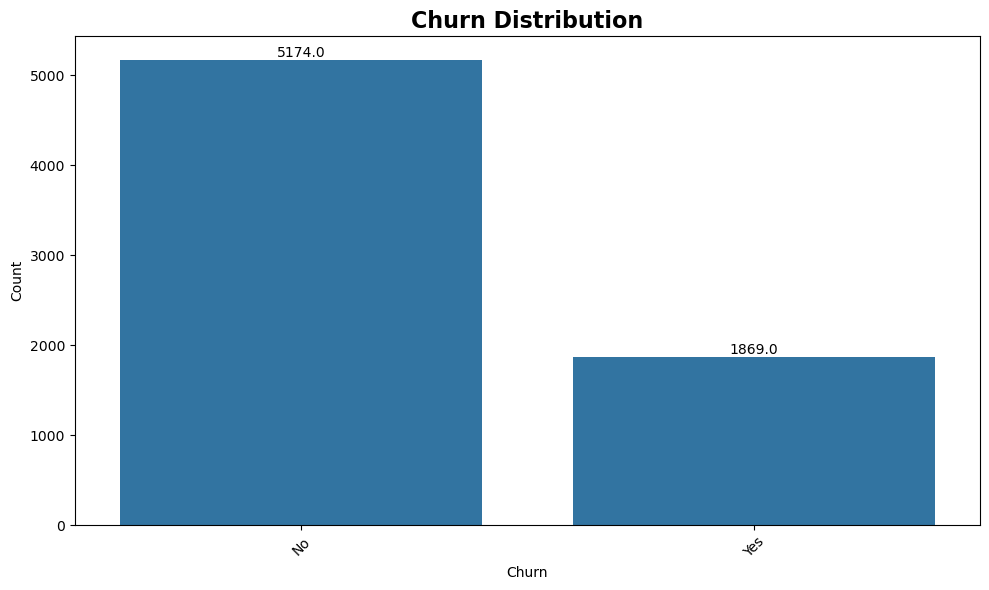


Gender Distribution:
gender
Male      0.504756
Female    0.495244
Name: proportion, dtype: float64


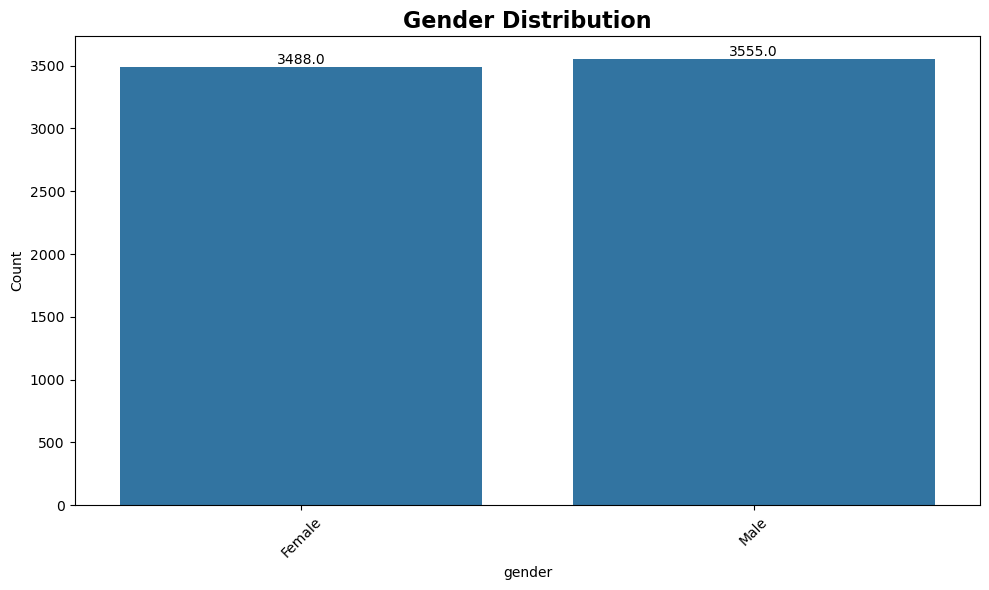


Senior Citizen Distribution:
SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64


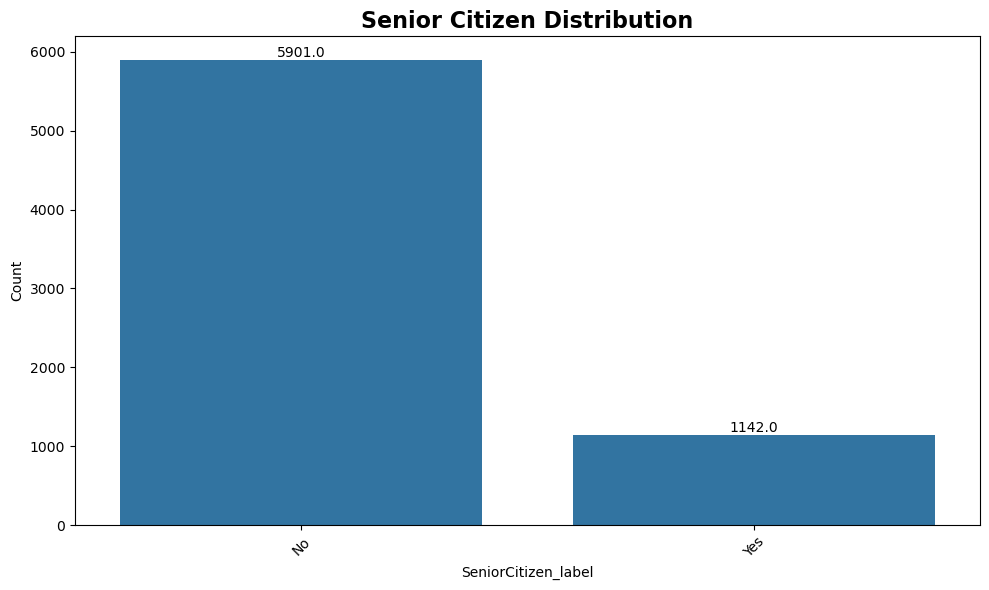


Partner Distribution:
Partner
No     0.516967
Yes    0.483033
Name: proportion, dtype: float64


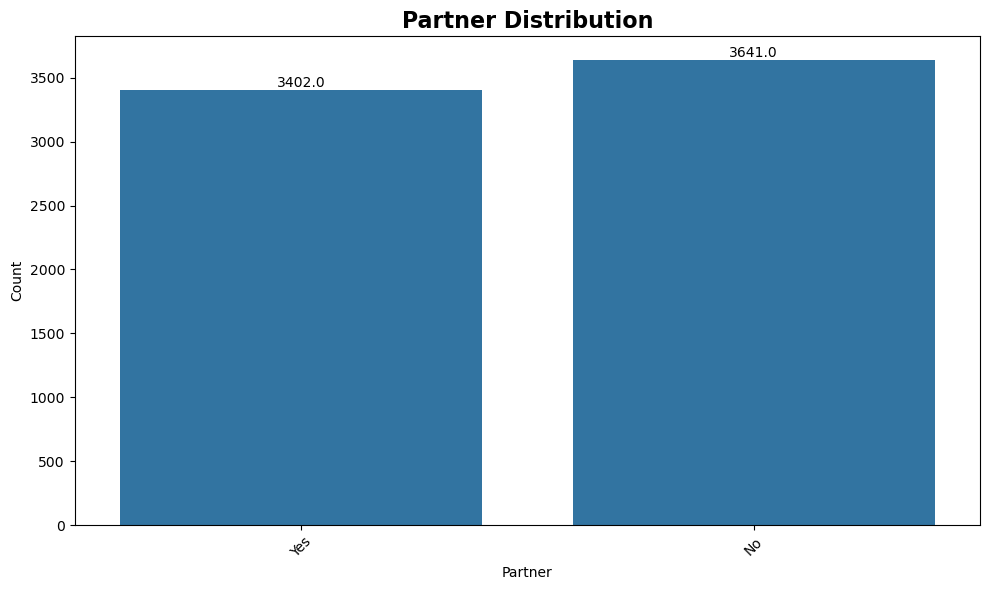


Dependents Distribution:
Dependents
No     0.700412
Yes    0.299588
Name: proportion, dtype: float64


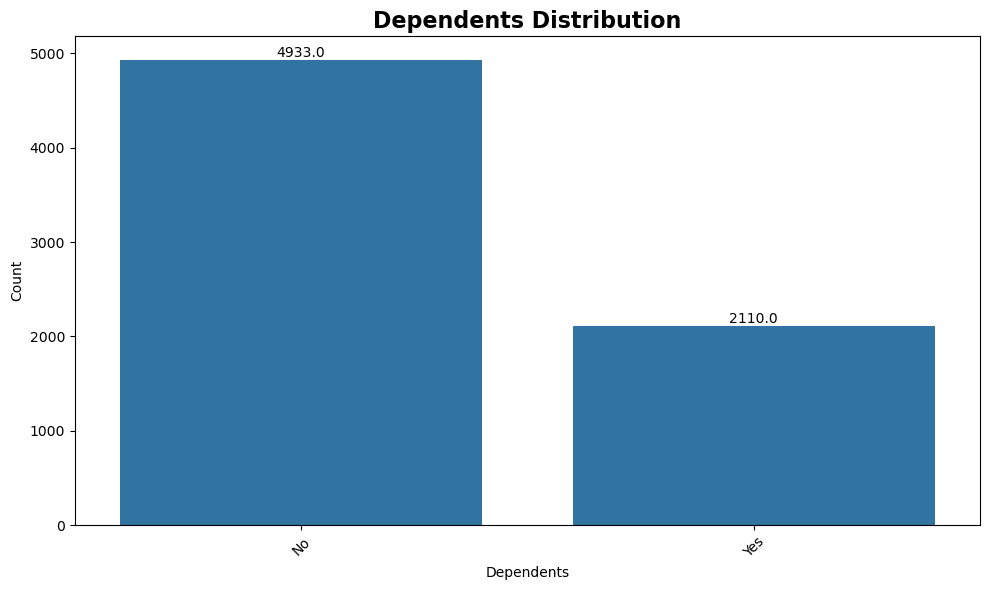


Numerical Features Summary:

tenure Statistics:
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


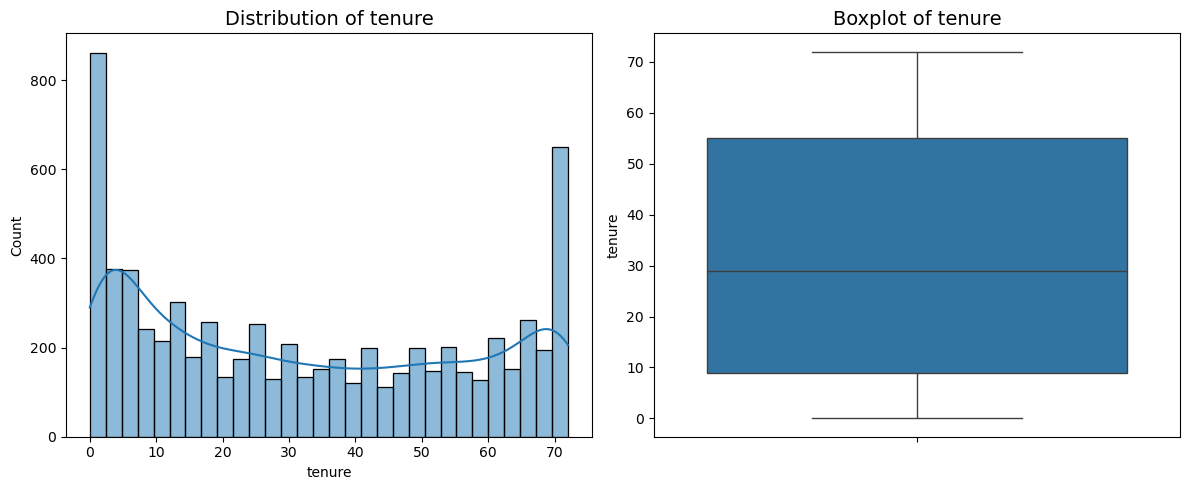


MonthlyCharges Statistics:
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


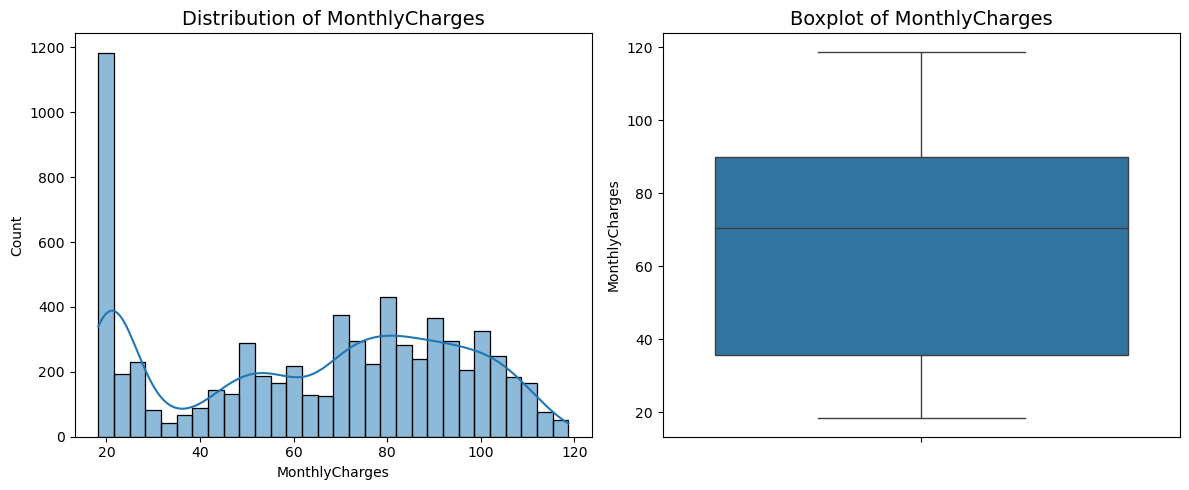


TotalCharges Statistics:
count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64


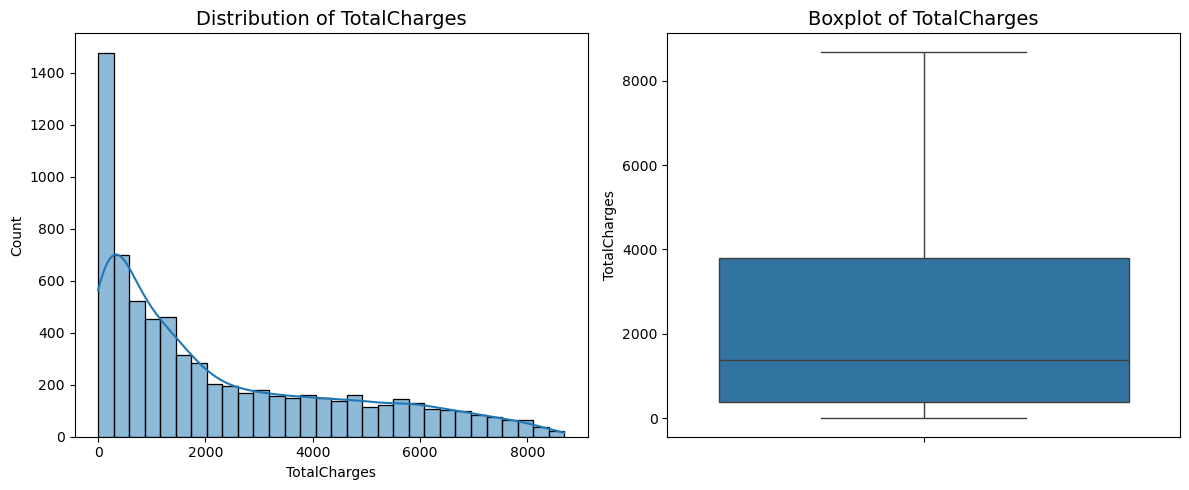

In [ ]:
print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print(f"Churn Rate: {df['Churn'].value_counts(normalize=True)[1]*100:.2f}%")
create_bar_plot(df, 'Churn', 'Churn Distribution')

# Analyze demographic features
print("\nGender Distribution:")
print(df['gender'].value_counts(normalize=True))
create_bar_plot(df, 'gender', 'Gender Distribution')

print("\nSenior Citizen Distribution:")
print(df['SeniorCitizen'].value_counts(normalize=True))
# Convert 0/1 to labels for better visualization
df['SeniorCitizen_label'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
create_bar_plot(df, 'SeniorCitizen_label', 'Senior Citizen Distribution')

print("\nPartner Distribution:")
print(df['Partner'].value_counts(normalize=True))
create_bar_plot(df, 'Partner', 'Partner Distribution')

print("\nDependents Distribution:")
print(df['Dependents'].value_counts(normalize=True))
create_bar_plot(df, 'Dependents', 'Dependents Distribution')

# Numerical features analysis
print("\nNumerical Features Summary:")
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    print(f"\n{col} Statistics:")
    print(df[col].describe())
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col, bins=30, kde=True)
    plt.title(f'Distribution of {col}', fontsize=14)
    
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot of {col}', fontsize=14)
    
    plt.tight_layout()
    plt.show()


Churn Rates by gender:
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338

Churn Rates by SeniorCitizen:
Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261

Churn Rates by Partner:
Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903

Churn Rates by Dependents:
Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237

Churn Rates by PhoneService:
Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637

Churn Rates by MultipleLines:
Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.39

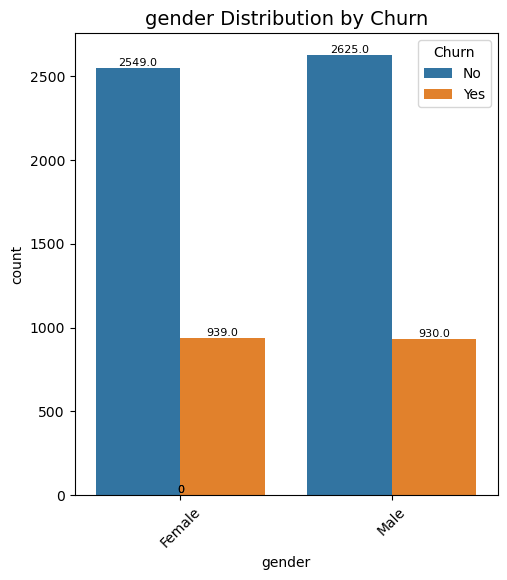

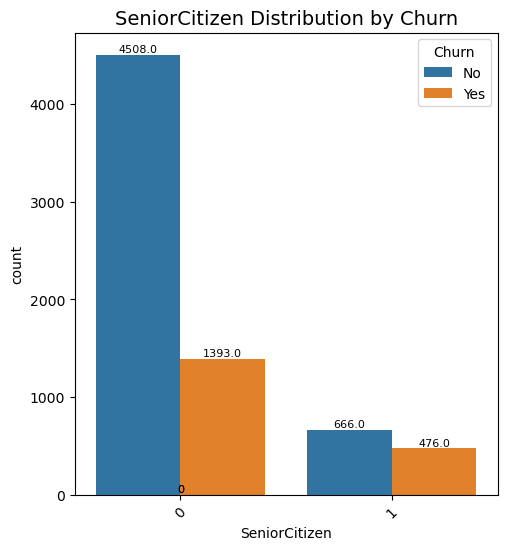

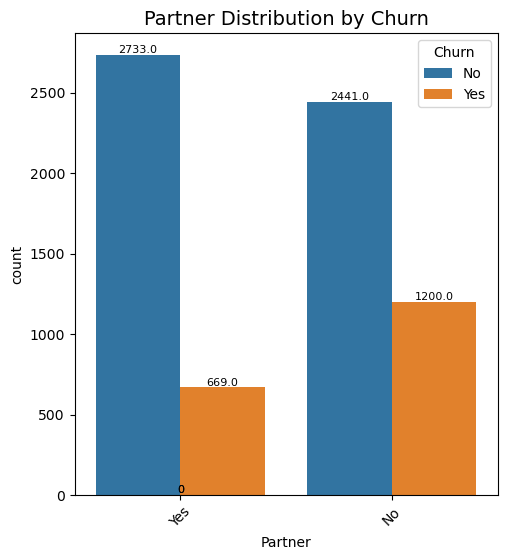

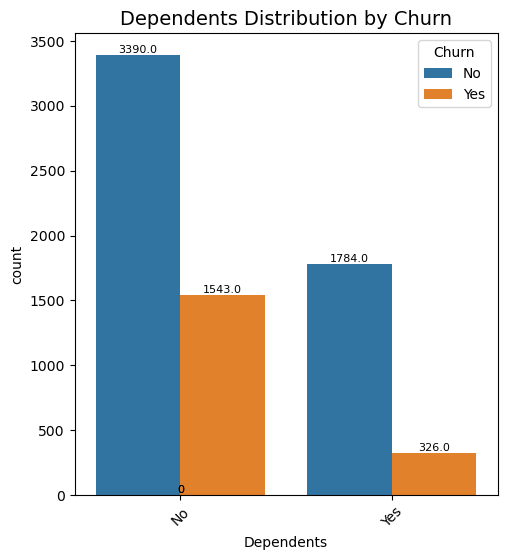

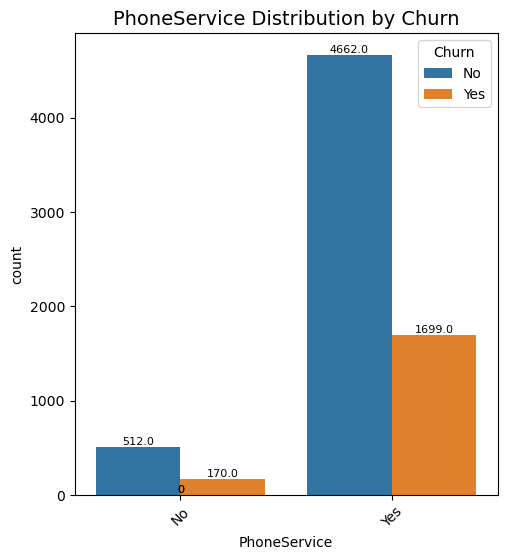

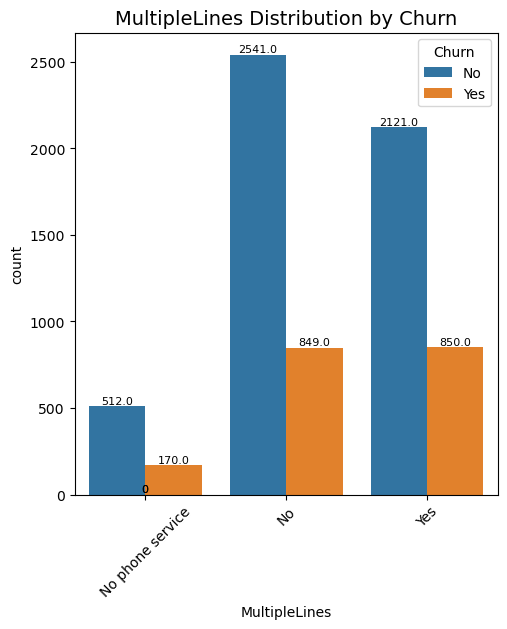

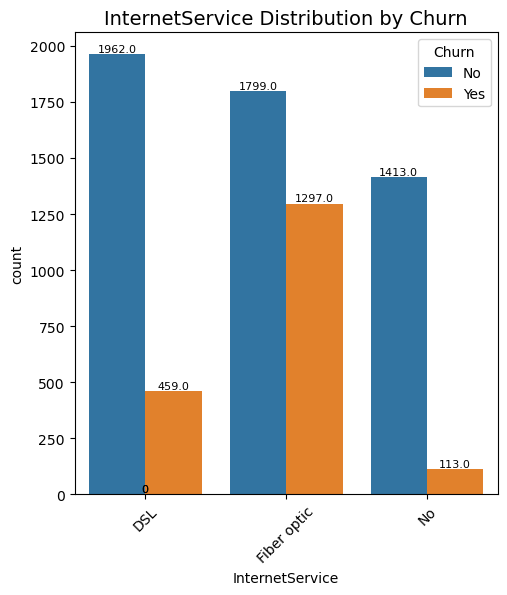

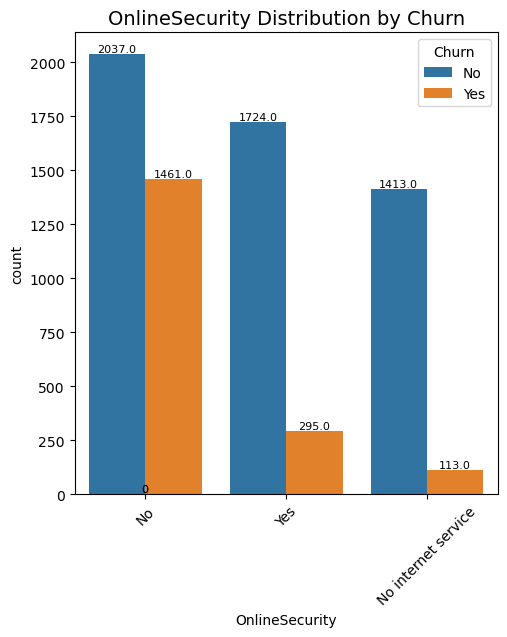

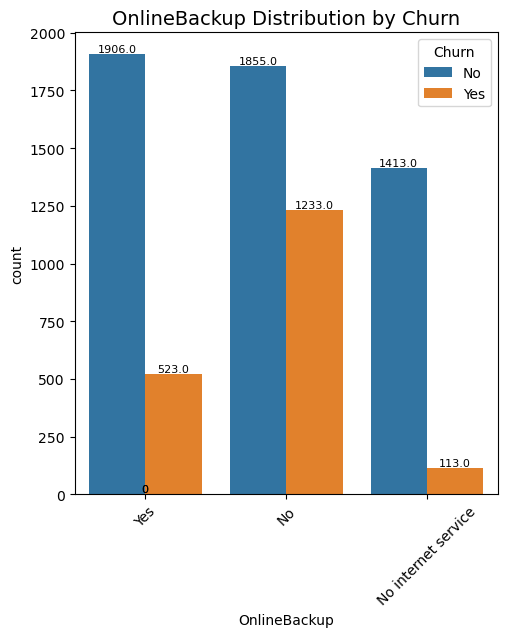

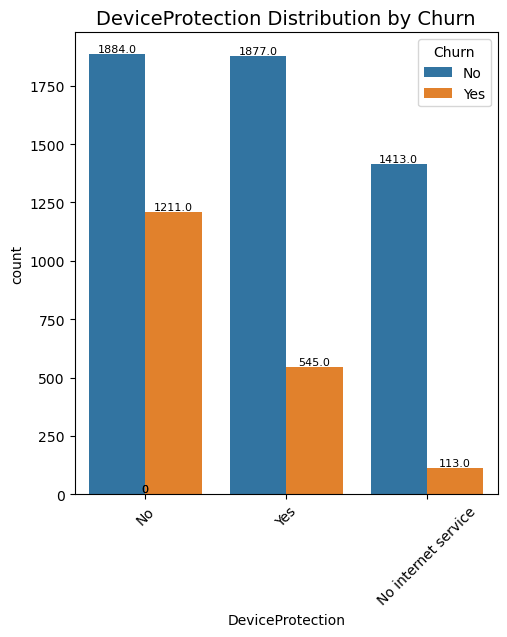

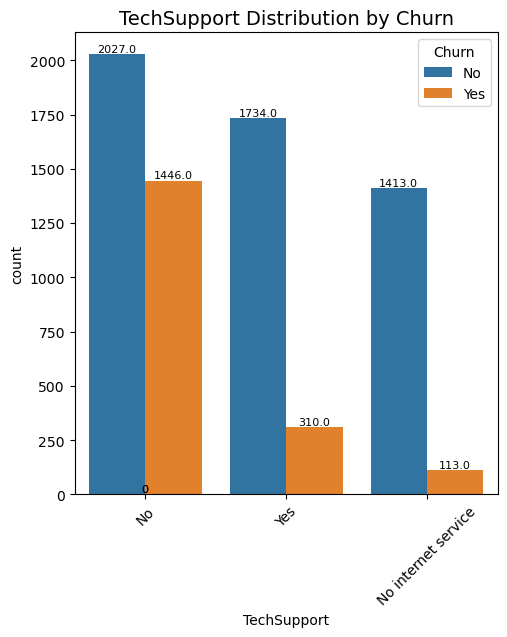

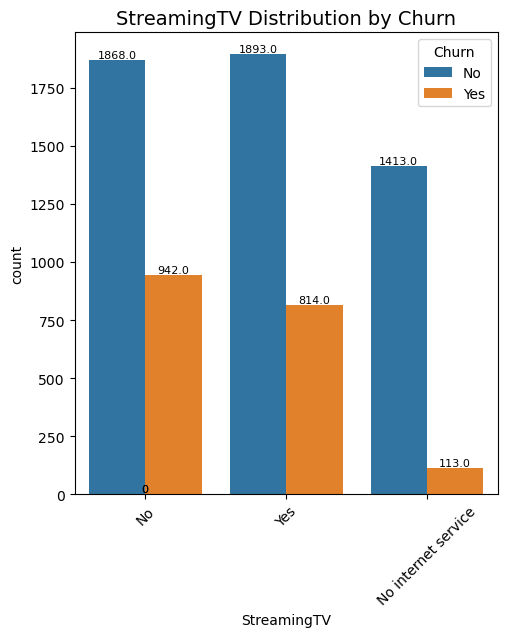

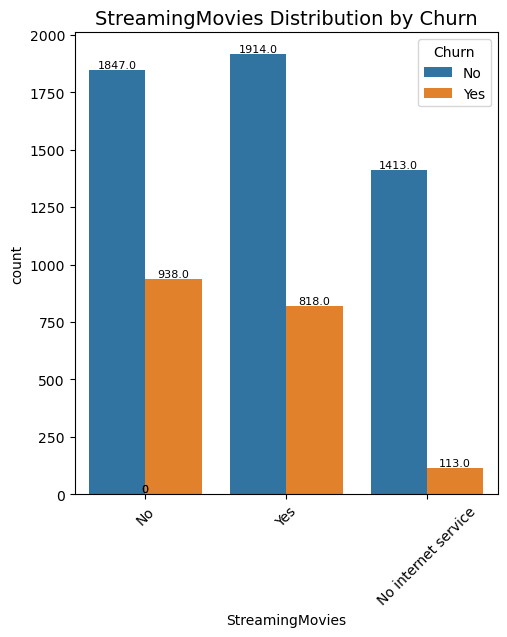

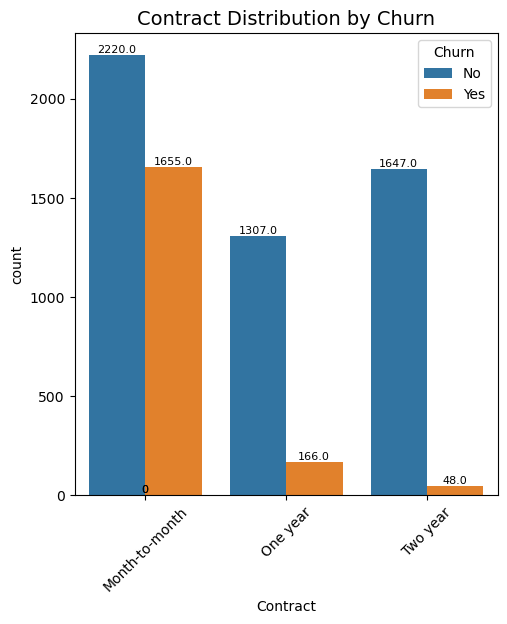

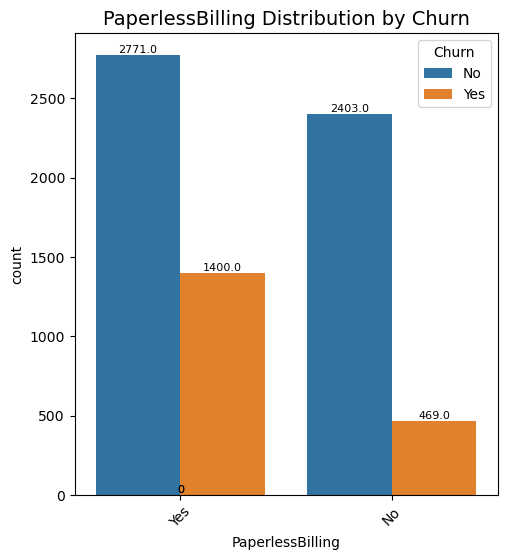

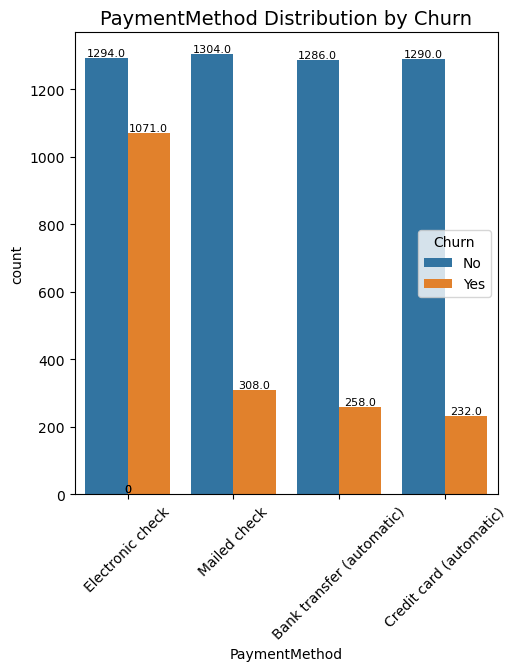

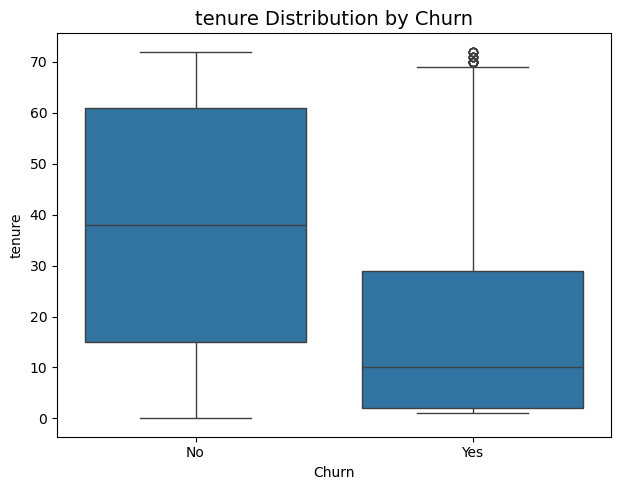


tenure Statistics by Churn:
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


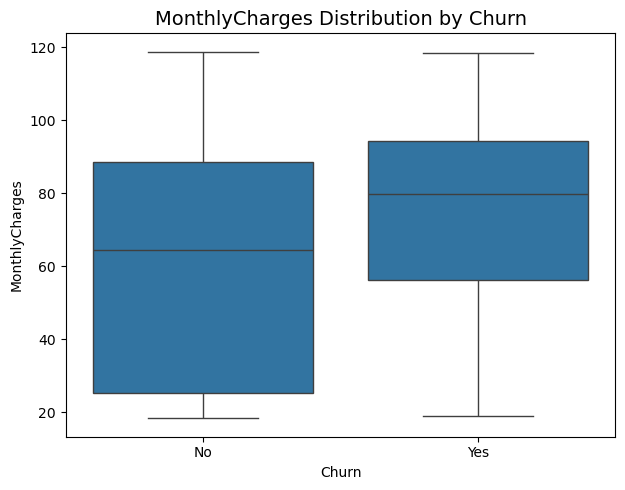


MonthlyCharges Statistics by Churn:
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


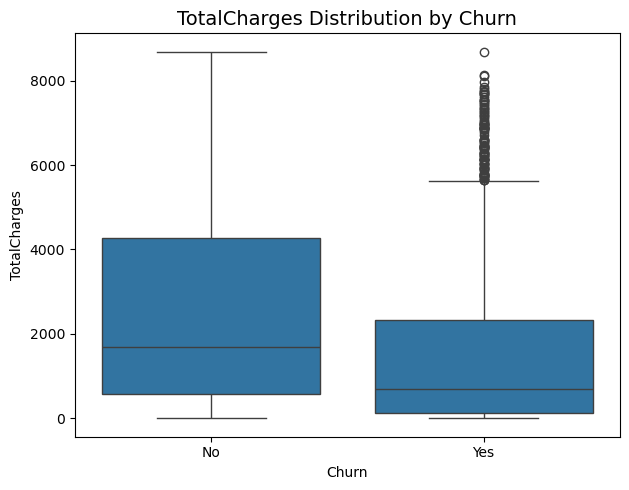


TotalCharges Statistics by Churn:
        count         mean          std    min    25%       50%      75%  \
Churn                                                                      
No     5174.0  2549.911442  2329.954215   0.00  572.9  1679.525  4262.85   
Yes    1869.0  1531.796094  1890.822994  18.85  134.5   703.550  2331.30   

           max  
Churn           
No     8672.45  
Yes    8684.80  


In [31]:
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                        'PhoneService', 'MultipleLines', 'InternetService',
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies',
                        'Contract', 'PaperlessBilling', 'PaymentMethod']

# Function to create churn comparison plots
def plot_churn_by_category(data, feature):
    plt.figure(figsize=(12, 6))
    
    # Count plot with hue
    plt.subplot(1, 2, 1)
    ax = sns.countplot(data=data, x=feature, hue='Churn')
    plt.title(f'{feature} Distribution by Churn', fontsize=14)
    plt.xticks(rotation=45)
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width()/2., p.get_height()), 
                   ha='center', va='bottom', fontsize=8)
    
   
    
    # Print churn rates
    print(f"\nChurn Rates by {feature}:")
    print(pd.crosstab(data[feature], data['Churn'], normalize='index') * 100)

# Analyze churn for each categorical feature
for feature in categorical_features[:]:  # Analyze first 5 features
    plot_churn_by_category(df, feature)

# Numerical features vs Churn
print("\nNumerical Features vs Churn:")
for col in numerical_cols:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(f'{col} Distribution by Churn', fontsize=14)
    
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{col} Statistics by Churn:")
    print(df.groupby('Churn')[col].describe())

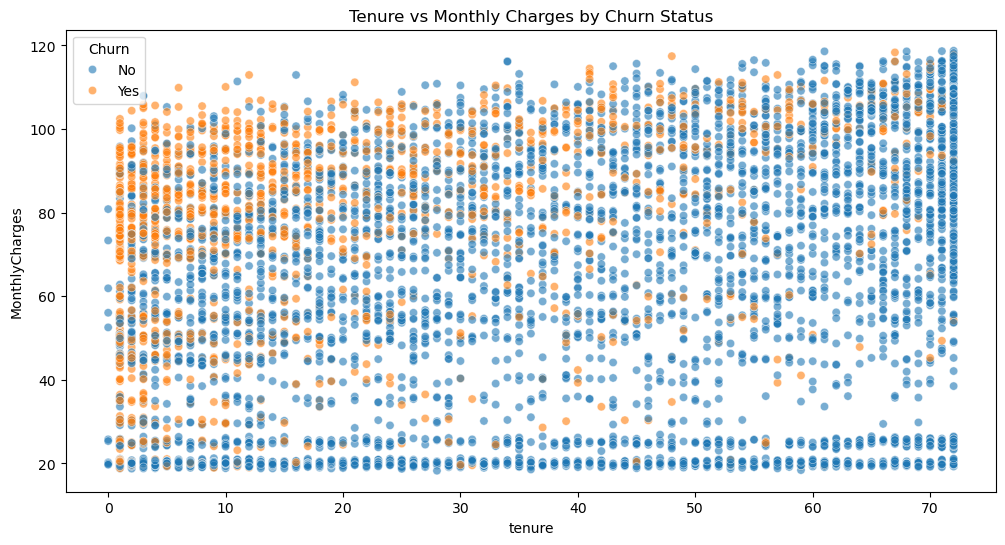

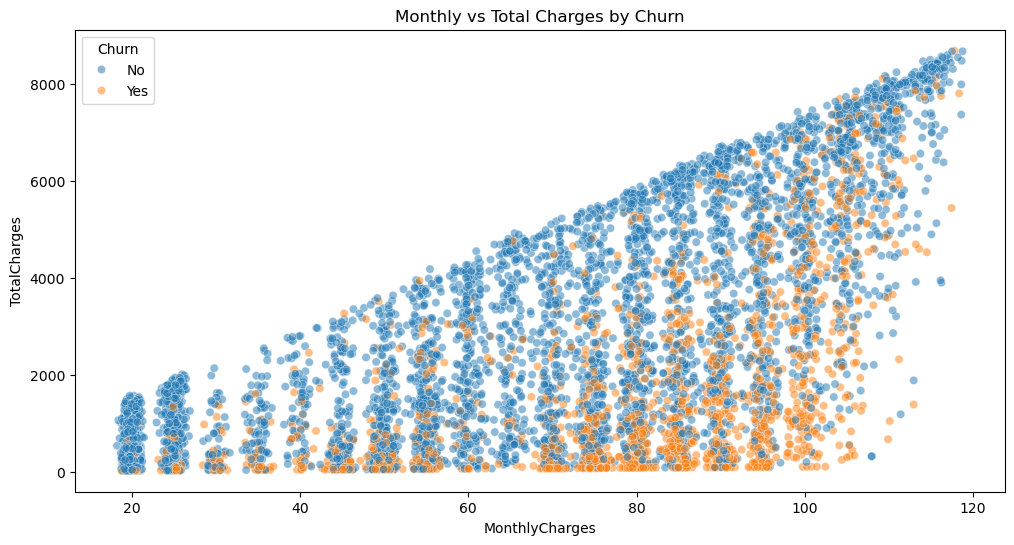

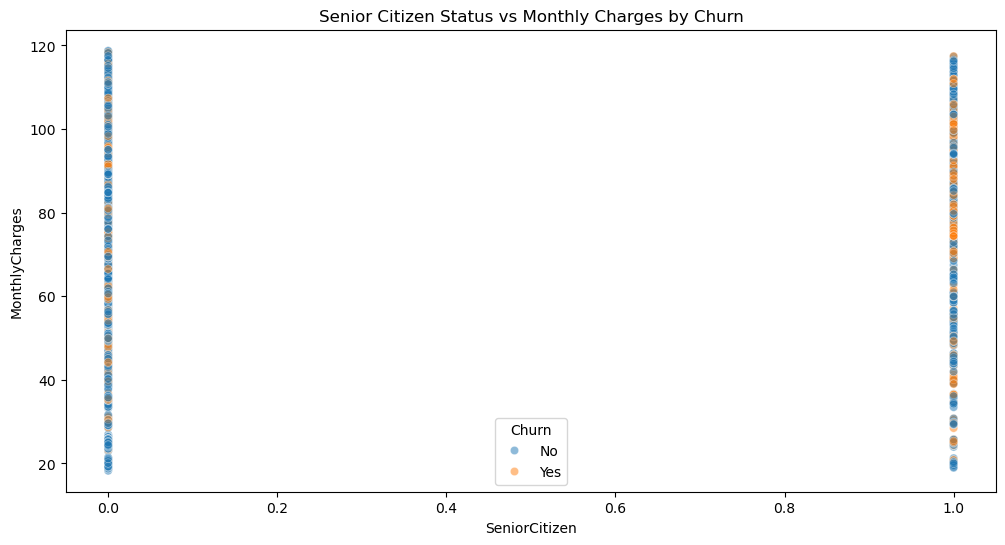

In [7]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', 
                hue='Churn', alpha=0.6)
plt.title('Tenure vs Monthly Charges by Churn Status')
plt.show()
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', 
                hue='Churn', alpha=0.5)
plt.title('Monthly vs Total Charges by Churn')
plt.show()
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='SeniorCitizen', y='MonthlyCharges', 
                hue='Churn', alpha=0.5)
plt.title('Senior Citizen Status vs Monthly Charges by Churn')
plt.show()

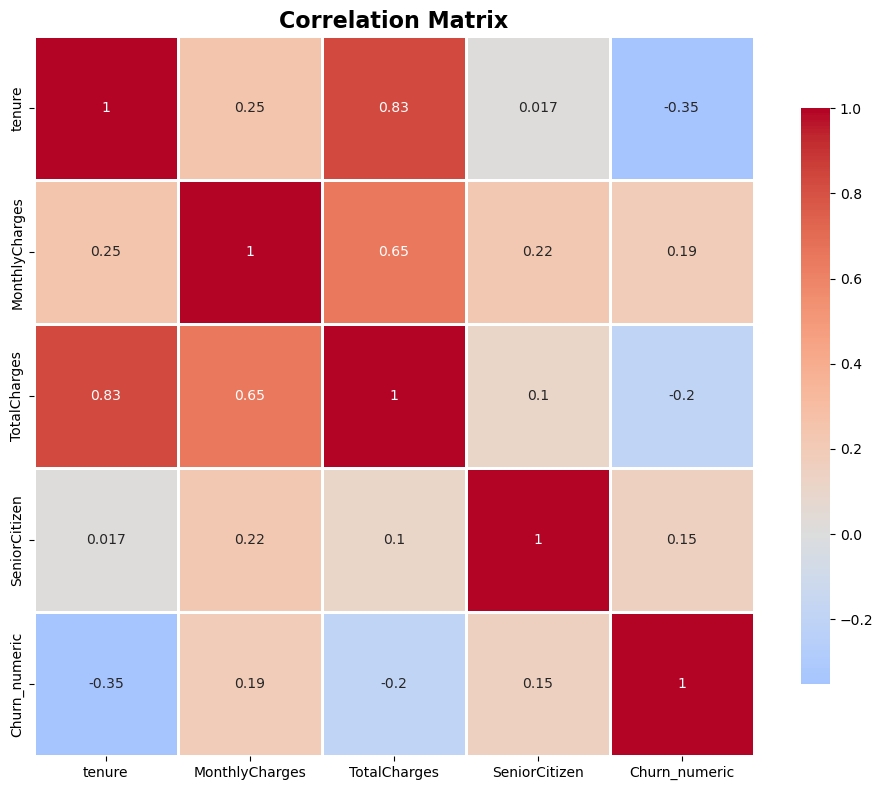


Correlation with Churn:
Churn_numeric     1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.198324
tenure           -0.352229
Name: Churn_numeric, dtype: float64


In [23]:
df['Churn_numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Select numerical columns for correlation
numerical_for_corr = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']

# Calculate correlation matrix
corr_matrix = df[numerical_for_corr].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with Churn:")
churn_corr = corr_matrix['Churn_numeric'].sort_values(ascending=False)
print(churn_corr)

In [24]:
print("\n1. Contract Type Impact:")
contract_churn = df.groupby('Contract')['Churn_numeric'].mean() * 100
for contract, rate in contract_churn.items():
    print(f"   {contract}: {rate:.1f}% churn rate")


1. Contract Type Impact:
   Month-to-month: 42.7% churn rate
   One year: 11.3% churn rate
   Two year: 2.8% churn rate


In [25]:
print("\n2. Internet Service Impact:")
internet_churn = df.groupby('InternetService')['Churn_numeric'].mean() * 100
for service, rate in internet_churn.items():
    print(f"   {service}: {rate:.1f}% churn rate")


2. Internet Service Impact:
   DSL: 19.0% churn rate
   Fiber optic: 41.9% churn rate
   No: 7.4% churn rate


In [26]:
print("\n3. Payment Method Impact:")
payment_churn = df.groupby('PaymentMethod')['Churn_numeric'].mean() * 100
for method, rate in payment_churn.sort_values(ascending=False).items():
    print(f"   {method}: {rate:.1f}% churn rate")


3. Payment Method Impact:
   Electronic check: 45.3% churn rate
   Mailed check: 19.1% churn rate
   Bank transfer (automatic): 16.7% churn rate
   Credit card (automatic): 15.2% churn rate


In [27]:
print("\n4. Online Security Impact:")
security_churn = df.groupby('OnlineSecurity')['Churn_numeric'].mean() * 100
for security, rate in security_churn.items():
    print(f"   {security}: {rate:.1f}% churn rate")



4. Online Security Impact:
   No: 41.8% churn rate
   No internet service: 7.4% churn rate
   Yes: 14.6% churn rate


In [28]:
print("\n5. Tech Support Impact:")
security_churn = df.groupby('TechSupport')['Churn_numeric'].mean() * 100
for security, rate in security_churn.items():
    print(f"   {security}: {rate:.1f}% churn rate")



5. Tech Support Impact:
   No: 41.6% churn rate
   No internet service: 7.4% churn rate
   Yes: 15.2% churn rate


In [29]:
print("\n" + "="*50)
print("HIGH-RISK CUSTOMER PROFILE:")
print("="*50)
print("• Month-to-month contract")
print("• Fiber optic internet service")
print("• No online security")
print("• No tech support")
print("• Electronic check payment method")
print("• Tenure less than 12 months")
print("• High monthly charges (> $70)")


HIGH-RISK CUSTOMER PROFILE:
• Month-to-month contract
• Fiber optic internet service
• No online security
• No tech support
• Electronic check payment method
• Tenure less than 12 months
• High monthly charges (> $70)


In [30]:
print("\n8. FINAL SUMMARY REPORT")
print("="*50)
print("\nTELCO CUSTOMER CHURN ANALYSIS SUMMARY")
print("="*50)

print(f"""
Dataset Overview:
----------------
Total Customers: {len(df):,}
Churned Customers: {df['Churn'].value_counts()['Yes']:,}
Churn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%

Key Findings:
------------
1. Contract Type: Month-to-month contracts have the highest churn rate
2. Tenure: New customers (first year) are most likely to churn
3. Internet Service: Fiber optic users show higher churn rates
4. Payment Method: Electronic check users have highest churn
5. Services: Customers without online security and tech support churn more

Recommendations:
---------------
1. Offer incentives for annual contracts
2. Improve onboarding for new customers
3. Provide bundled services with security features
4. Encourage automatic payment methods
5. Target high-risk customers with retention offers
""")

# Save cleaned data for further analysis
df.to_csv('Telco_Customer_Churn_Cleaned.csv', index=False)
print("\n Cleaned data saved to 'Telco_Customer_Churn_Cleaned.csv'")


8. FINAL SUMMARY REPORT

TELCO CUSTOMER CHURN ANALYSIS SUMMARY

Dataset Overview:
----------------
Total Customers: 7,043
Churned Customers: 1,869
Churn Rate: 26.5%

Key Findings:
------------
1. Contract Type: Month-to-month contracts have the highest churn rate
2. Tenure: New customers (first year) are most likely to churn
3. Internet Service: Fiber optic users show higher churn rates
4. Payment Method: Electronic check users have highest churn
5. Services: Customers without online security and tech support churn more

Recommendations:
---------------
1. Offer incentives for annual contracts
2. Improve onboarding for new customers
3. Provide bundled services with security features
4. Encourage automatic payment methods
5. Target high-risk customers with retention offers


 Cleaned data saved to 'Telco_Customer_Churn_Cleaned.csv'
